In [3]:
! pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import STOPWORDS, WordCloud

In [83]:
df = pd.read_csv("emails.csv")
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [84]:
df.shape

(5728, 2)

In [85]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

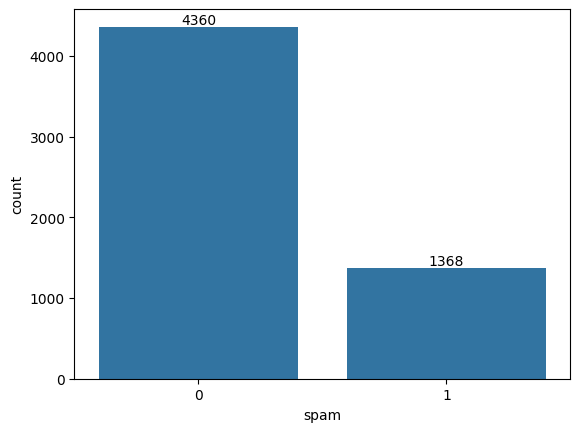

In [86]:
ax = sns.countplot(x = df.spam)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
               (bar.get_x() + bar.get_width() / 2, height),
                ha = 'center',
                va = 'bottom'
               )
plt.show()

In [87]:
pos = df[df['spam'] == 0]
pos

,text,spam
1368,"Subject: hello guys , i ' m "" bugging you "" f...",0
1369,Subject: sacramento weather station fyi - - ...,0
1370,Subject: from the enron india newsdesk - jan 1...,0
1371,Subject: re : powerisk 2001 - your invitation ...,0
1372,Subject: re : resco database and customer capt...,0
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [88]:
neg = df[df['spam'] == 1]
neg

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1
1364,Subject: would you like a $ 250 gas card ? do...,1
1365,"Subject: immediate reply needed dear sir , i...",1
1366,Subject: wanna see me get fisted ? fist bang...,1


In [89]:
stop_words = STOPWORDS
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [90]:
posit = list(df[df['spam'] == 0]['text'])
negative = list(df[df['spam'] == 1]['text'])

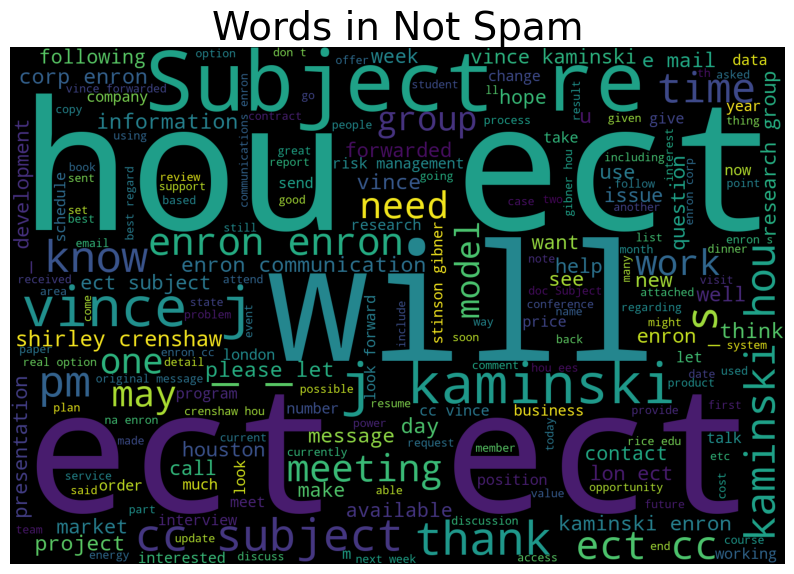

In [91]:
# Word Cloud
def create_cloud(string):
    cloud = WordCloud(
        height=1000,
        width=1500,
        min_font_size=10,
        stopwords=STOPWORDS
    ).generate(string)

    plt.figure(figsize=(10,10))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title("Words in Not Spam", fontdict={"fontsize":28})
    plt.show()

create_cloud(" ".join(posit))

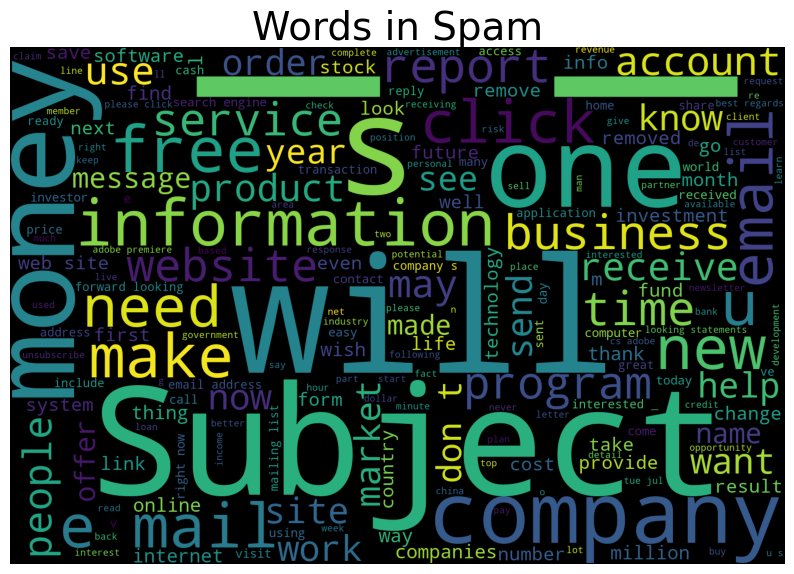

In [92]:
# Word Cloud
def create_cloud(string):
    cloud = WordCloud(
        height=1000,
        width=1500,
        min_font_size=10,
        stopwords=STOPWORDS
    ).generate(string)

    plt.figure(figsize=(10,10))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title("Words in Spam", fontdict={"fontsize":28})
    plt.show()

create_cloud(" ".join(negative))

In [93]:
# Text Preprocessing
import re
import string
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

def text_processing(data):
    
    stop_words = set(stopwords.words('english'))
    porter = PorterStemmer()

    def decontracted(text):
        text = re.sub(r"won't", "will not", text)
        text = re.sub(r"can't", "can not", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"'m", " am", text)
        return text

    processed_text = []

    for sentence in data:

        # Remove HTML tags
        #sentence = BeautifulSoup(sentence, "lxml").get_text()
        sentence = BeautifulSoup(sentence, "html.parser").get_text()

        # Remove URLs
        sentence = re.sub(r"http\S+|www\S+", "", sentence)

        # Expand contractions
        sentence = decontracted(sentence)

        # Lowercase
        sentence = sentence.lower()

        # Remove digits
        sentence = re.sub(r'\d+', '', sentence)

        # Remove punctuation
        sentence = sentence.translate(str.maketrans('', '', string.punctuation))

        # Remove stopwords + stemming
        words = [
            porter.stem(word)
            for word in sentence.split()
            if word not in stop_words
        ]

        processed_text.append(" ".join(words))

    return processed_text

In [94]:
df['cleaned_text'] = text_processing(df['text'])

In [95]:
df.head()

,text,spam,cleaned_text
0,Subject: naturally irresistible your corporate...,1,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,subject color print special request addit info...
4,"Subject: do not have money , get software cds ...",1,subject money get softwar cd softwar compat gr...


In [96]:
x = df['cleaned_text']
y = df['spam']

In [97]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [98]:
# vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer()


In [99]:
tf_train = tf.fit_transform(xtrain)
tf_test = tf.transform(xtest)

In [100]:
tf_train.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [101]:
tf_test.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [102]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
mn = MultinomialNB()

In [103]:
mn.fit(tf_train, ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [104]:
mn.score(tf_train, ytrain)

0.926887821911829

In [105]:
mn.score(tf_test, ytest)

0.8769633507853403

In [106]:
tf_train.shape

(4582, 23092)

In [107]:
pred = mn.predict(tf_test)
pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [108]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, auc

In [109]:
print('Accuracy Score: ', accuracy_score(ytest, pred))

Accuracy Score:  0.8769633507853403


In [110]:
print('Classification Report: \n',classification_report(ytest, pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.86      1.00      0.92       856
           1       1.00      0.51      0.68       290

    accuracy                           0.88      1146
   macro avg       0.93      0.76      0.80      1146
weighted avg       0.89      0.88      0.86      1146



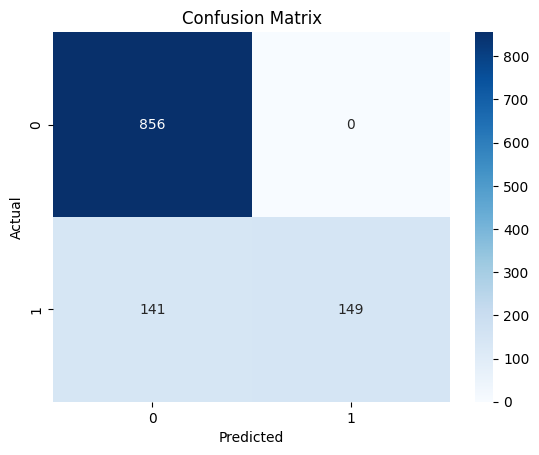

In [111]:
cm = confusion_matrix(ytest, pred)

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

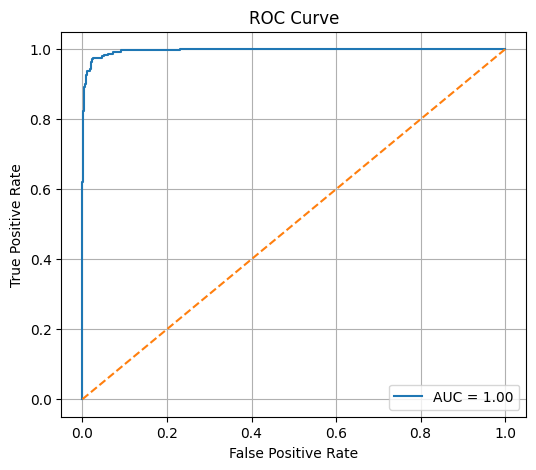

In [112]:
# RoC AUC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
y_prob = mn.predict_proba(tf_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(ytest, y_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')   # Random guess line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [113]:
# Model Save
import pickle

naive_bayes_model = pickle.dump(mn, open("naive_bayes_model","wb"))

In [114]:
# Vector save
vector_model = pickle.dump(tf,open("tf_model","wb"))

In [126]:
# Load Models
load_bayes_model=pickle.load(open("naive_bayes_model",'rb'))
vector_model = pickle.load(open("tf_model","rb"))

In [127]:
load_bayes_model.score(tf_test,ytest)

0.8769633507853403

In [128]:
# Test case

In [129]:
test_spam = "Congratulations! You have won a $1000 Walmart gift card. Click the link now to claim your prize before it expires. Hurry! Limited time offer."

In [130]:
test_non_spam = "Hi Omar, the class has been rescheduled to 10 AM tomorrow. Please bring your assignment notebook with you." 

In [131]:
# Text Preprocessing
import re
import string
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

def text_processing(data):
    
    stop_words = set(stopwords.words('english'))
    porter = PorterStemmer()

    def decontracted(text):
        text = re.sub(r"won't", "will not", text)
        text = re.sub(r"can't", "can not", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"'m", " am", text)
        return text

    processed_text = []

    for sentence in data:

        # Remove HTML tags
        #sentence = BeautifulSoup(sentence, "lxml").get_text()
        sentence = BeautifulSoup(sentence, "html.parser").get_text()

        # Remove URLs
        sentence = re.sub(r"http\S+|www\S+", "", sentence)

        # Expand contractions
        sentence = decontracted(sentence)

        # Lowercase
        sentence = sentence.lower()

        # Remove digits
        sentence = re.sub(r'\d+', '', sentence)

        # Remove punctuation
        sentence = sentence.translate(str.maketrans('', '', string.punctuation))

        # Remove stopwords + stemming
        words = [
            porter.stem(word)
            for word in sentence.split()
            if word not in stop_words
        ]

        processed_text.append(" ".join(words))

    return processed_text

In [138]:
clean = text_processing(test_non_spam)

In [139]:
clean

['h',
 '',
 '',
 '',
 '',
 '',
 'r',
 '',
 '',
 '',
 'h',
 'e',
 '',
 'c',
 'l',
 '',
 '',
 '',
 '',
 'h',
 '',
 '',
 '',
 'b',
 'e',
 'e',
 'n',
 '',
 'r',
 'e',
 '',
 'c',
 'h',
 'e',
 '',
 'u',
 'l',
 'e',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 'r',
 'r',
 '',
 'w',
 '',
 '',
 'p',
 'l',
 'e',
 '',
 '',
 'e',
 '',
 'b',
 'r',
 '',
 'n',
 'g',
 '',
 '',
 '',
 'u',
 'r',
 '',
 '',
 '',
 '',
 '',
 'g',
 'n',
 '',
 'e',
 'n',
 '',
 '',
 'n',
 '',
 '',
 'e',
 'b',
 '',
 '',
 'k',
 '',
 'w',
 '',
 '',
 'h',
 '',
 '',
 '',
 'u',
 '']

In [140]:
vec_test = vector_model.transform(clean)

In [141]:
vec_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (106, 23092)>

In [142]:
prediction = load_bayes_model.predict(vec_test)

In [143]:
prediction

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)